# Bài thực hành 1

## Vấn đề 
_Dự đoán khả năng tiến triển của bệnh tiểu đường thông qua các chỉ số sinh lý của cơ thể._


## Thông tin dữ liệu:

- Số lượng mẫu: 442 (thông tin từ 442 bệnh nhân)
- Số lượng thuộc tính:
    Thông tin các thuộc tính (10 cột giá trị đầu tiên): Age(tuổi), Sex (giới tính), 
    Body mass index (chỉ số khối cơ thể), Average blood pressure(huyết ap trung bình), S1, S2, S3, S4, S5, S6 (sáu phép đo huyết thanh khác).
- Mục tiêu:	Cột 11, chỉ số đánh giá mức độ tiến triển của bệnh 1 năm sau khi điều trị. 

**! Chú ý: Dữ liệu thông tin thuộc tính đã được chuẩn hoá**

Xem thêm thông tin về nguồn dữ liệu tại: (https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import math 
import seaborn as sns
from sklearn import datasets, linear_model
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error
from sklearn.model_selection import train_test_split

#Load dữ liệu

In [3]:
data = datasets.load_diabetes()
data_train = data.data
data_target = data.target

#Chia dữ liệu train_test

In [4]:
X_train,X_test,y_train,y_test = train_test_split(data_train,data_target, test_size = 0.2, random_state = 42)

#Huấn luyện mô hình linear_regression

In [5]:

model_linear = LinearRegression()
model_linear.fit(X_train,y_train)
print(f'Hệ số chặn là: w0 = {model_linear.intercept_}')
print(f'Vector trọng số là : w = {model_linear.coef_}')

Hệ số chặn là: w0 = 151.34560453985995
Vector trọng số là : w = [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]


#Huấn luyện mô hình Ridge_regression

In [6]:

model_ridge = Ridge(alpha = 0.1)
model_ridge.fit(X_train,y_train)
print(f'Hệ số chặn là: w0 = {model_ridge.intercept_}')
print(f'Vector trọng số là : w = {model_ridge.coef_}')

Hệ số chặn là: w0 = 151.45857456679613
Vector trọng số là : w = [  42.85566976 -205.49431899  505.08903304  317.0932049  -108.50026183
  -86.23673333 -190.36318008  151.70708637  392.28931896   79.9081772 ]


# Dự đoán các mẫu dữ liệu trong tập test 

#Dự đoán bằng mô hình Ridge Regreesion

In [7]:
y_pred_rid =  model_ridge.predict(X_test)
df = pd.DataFrame({'Giá thật': y_test, 'Giá dự đoán': y_pred_rid})
df['Chênh lệch'] = abs(df['Giá dự đoán'] - df['Giá thật'])
df

,Giá thật,Giá dự đoán,Chênh lệch
0,219.0,143.864481,75.135519
1,70.0,177.606731,107.606731
2,202.0,143.035780,58.964220
3,230.0,286.633016,56.633016
4,111.0,125.616408,14.616408
...,...,...,...
84,153.0,113.712026,39.287974
85,98.0,88.879145,9.120855
86,37.0,81.247179,44.247179
87,63.0,66.132387,3.132387


#Dự đoán bằng mô hình Linear Regreesion

In [8]:
y_pred_linear =  model_linear.predict(X_test)
df = pd.DataFrame({'Giá thật': y_test, 'Giá dự đoán': y_pred_linear})
df['Chênh lệch'] = abs(df['Giá dự đoán'] - df['Giá thật'])
df

,Giá thật,Giá dự đoán,Chênh lệch
0,219.0,139.547558,79.452442
1,70.0,179.517208,109.517208
2,202.0,134.038756,67.961244
3,230.0,291.417029,61.417029
4,111.0,123.789659,12.789659
...,...,...,...
84,153.0,115.011800,37.988200
85,98.0,78.955842,19.044158
86,37.0,81.560873,44.560873
87,63.0,54.379973,8.620027


#Đánh giá chỉ số RMSE

In [9]:
rmse_Score_linear = root_mean_squared_error(y_test, y_pred_linear)
rmse_Score_rid = root_mean_squared_error(y_test, y_pred_rid)
print(f'Chỉ số rmse của mô hình linear:{rmse_Score_linear}')
print(f'Chỉ số rmse của mô hình rid:{rmse_Score_rid}')

Chỉ số rmse của mô hình linear:53.85344583676592
Chỉ số rmse của mô hình rid:53.44611199769965


In [10]:
##### exercise #####
# Yêu cầu: đánh giá độ đo RMSE của mô hình Ridge Regression với các hằng số phạt khác nhau, in ra kết quả.
# Gợi ý: Các bước làm:
# - Lặp theo danh sách các hằng số phạt
# - Dựng các mô hình Ridge Regression với mỗi hằng số phạt tương ứng
# - Huấn luyện các mô hình và dự đoán 
# - Tính RMSE tương ứng
######################

#Các giá trị hằng số phạt cho trước
_lambda = [0, 0.0001,0.01, 0.04, 0.05, 0.06, 0.1, 0.5, 1, 5, 10, 20]

In [11]:
for alpha in _lambda:
    model_ridge = Ridge(alpha=alpha)
    model_ridge.fit(X_train,y_train)
    y_pred_rid = model_ridge.predict(X_test)
    rmse_Score_rid = root_mean_squared_error(y_test, y_pred_rid)    
    print(f'Chỉ số rmse của mô hình rid với alpha = {alpha} là {rmse_Score_rid}')


Chỉ số rmse của mô hình rid với alpha = 0 là 53.85344583676594
Chỉ số rmse của mô hình rid với alpha = 0.0001 là 53.84867157029346
Chỉ số rmse của mô hình rid với alpha = 0.01 là 53.6869647158974
Chỉ số rmse của mô hình rid với alpha = 0.04 là 53.565914219398515
Chỉ số rmse của mô hình rid với alpha = 0.05 là 53.537926129269216
Chỉ số rmse của mô hình rid với alpha = 0.06 là 53.51352140152274
Chỉ số rmse của mô hình rid với alpha = 0.1 là 53.44611199769965
Chỉ số rmse của mô hình rid với alpha = 0.5 là 54.01089328532645
Chỉ số rmse của mô hình rid với alpha = 1 là 55.47446204180109
Chỉ số rmse của mô hình rid với alpha = 5 là 63.040003387897364
Chỉ số rmse của mô hình rid với alpha = 10 là 66.66297800625937
Chỉ số rmse của mô hình rid với alpha = 20 là 69.40143115231396


## Vẽ biểu đồ phân phối cho chỉ số thực tế

In [13]:
##### exercise #####
# Yêu cầu: Tính các chỉ số thống kê và vẽ biểu đồ phân phối của chỉ số dự đoán bằng mô hình Linear Regression, quan sát và nhận xét
# Gợi ý: sử dụng sns và pd
######################
df = pd.DataFrame(y_pred_linear).describe()
df.columns = ['Giá trị']
df

,Giá trị
count,89.000000
mean,141.862441
std,54.346521
min,47.990466
25%,100.129259
50%,144.810309
75%,181.337321
max,291.417029


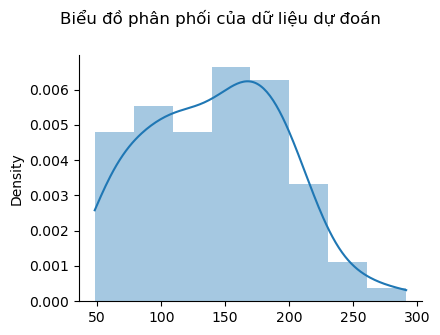

In [35]:

g = sns.displot(y_pred_linear,alpha = .4,edgecolor = 'None', kde = True, height = 3, aspect=1.5, stat = 'density')
g.fig.suptitle('Biểu đồ phân phối của dữ liệu dự đoán', y = 1.1)
plt.show()

## Vẽ biểu đồ so sánh kết quả dự đoán và thực tế

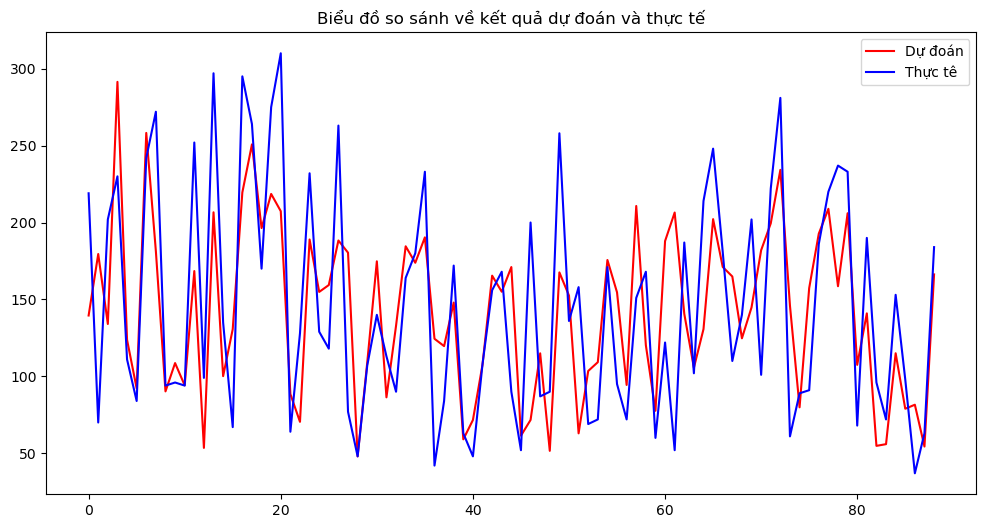

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_pred_linear, color = 'red', label = 'Dự đoán')
plt.plot(y_test, color = 'blue', label = 'Thực tê')
plt.legend()
plt.xlabel('Patients')
plt.ylabel('Index')
plt.title('Biểu đồ so sánh về kết quả dự đoán và thực tế')
plt.show()